In [1]:
import re
import io
import os
import numpy as np
import pandas as pd
import scipy.interpolate
import scipy.optimize
from parse_rating import parse_rating
import matplotlib.pyplot as plt

In [2]:
cfs_to_cms = 0.0283168
ft_to_m = 0.3048

In [3]:
hand_table = pd.read_csv('hydroTable.csv')

In [4]:
gageid_to_hydroid = pd.read_excel('USGSHoustonGauges_Project_TableToExcel.xlsx')
gageid_to_hydroid['stationid'] = gageid_to_hydroid['stationid'].str[2:]
gageid_to_hydroid = gageid_to_hydroid[['stationid', 'HydroID']].set_index('stationid')['HydroID']

In [5]:
usgs_ratings = {}
for station_id in gageid_to_hydroid.index:
    filename = f'./usgs_ratings/USGS.{station_id}.base.rdb'
    if os.path.exists(filename):
        usgs_rating = parse_rating(filename)
        usgs_rating['INDEP'] -= usgs_rating['INDEP'].min()
        usgs_rating['INDEP'] *= ft_to_m
        usgs_rating['DEP'] *= cfs_to_cms
        usgs_ratings[station_id] = usgs_rating

In [6]:
hand_ratings = {}
for station_id in gageid_to_hydroid.index:
    hydroid = gageid_to_hydroid[station_id]
    reach_table = hand_table[hand_table['HydroID'] == hydroid]
    hand_rating = reach_table[['stage', 'discharge_cms', 'HydraulicRadius (m)', 'WetArea (m2)', 'SLOPE', 'ManningN']]
    hand_ratings[station_id] = hand_rating
    

In [7]:
valid_ids = [station_id for station_id in gageid_to_hydroid.index if station_id in usgs_ratings]

In [8]:
def eval_hand(n, A, R, S_0):
    Q_hand = (1 / n) * A * R**(2/3) * np.sqrt(S_0)
    return Q_hand

def eval_curves(n, A, R, S_0, Qref):
    Q_hand = eval_hand(n, A, R, S_0)
    Q_usgs = Qref
    return np.linalg.norm(Q_hand - Q_usgs)

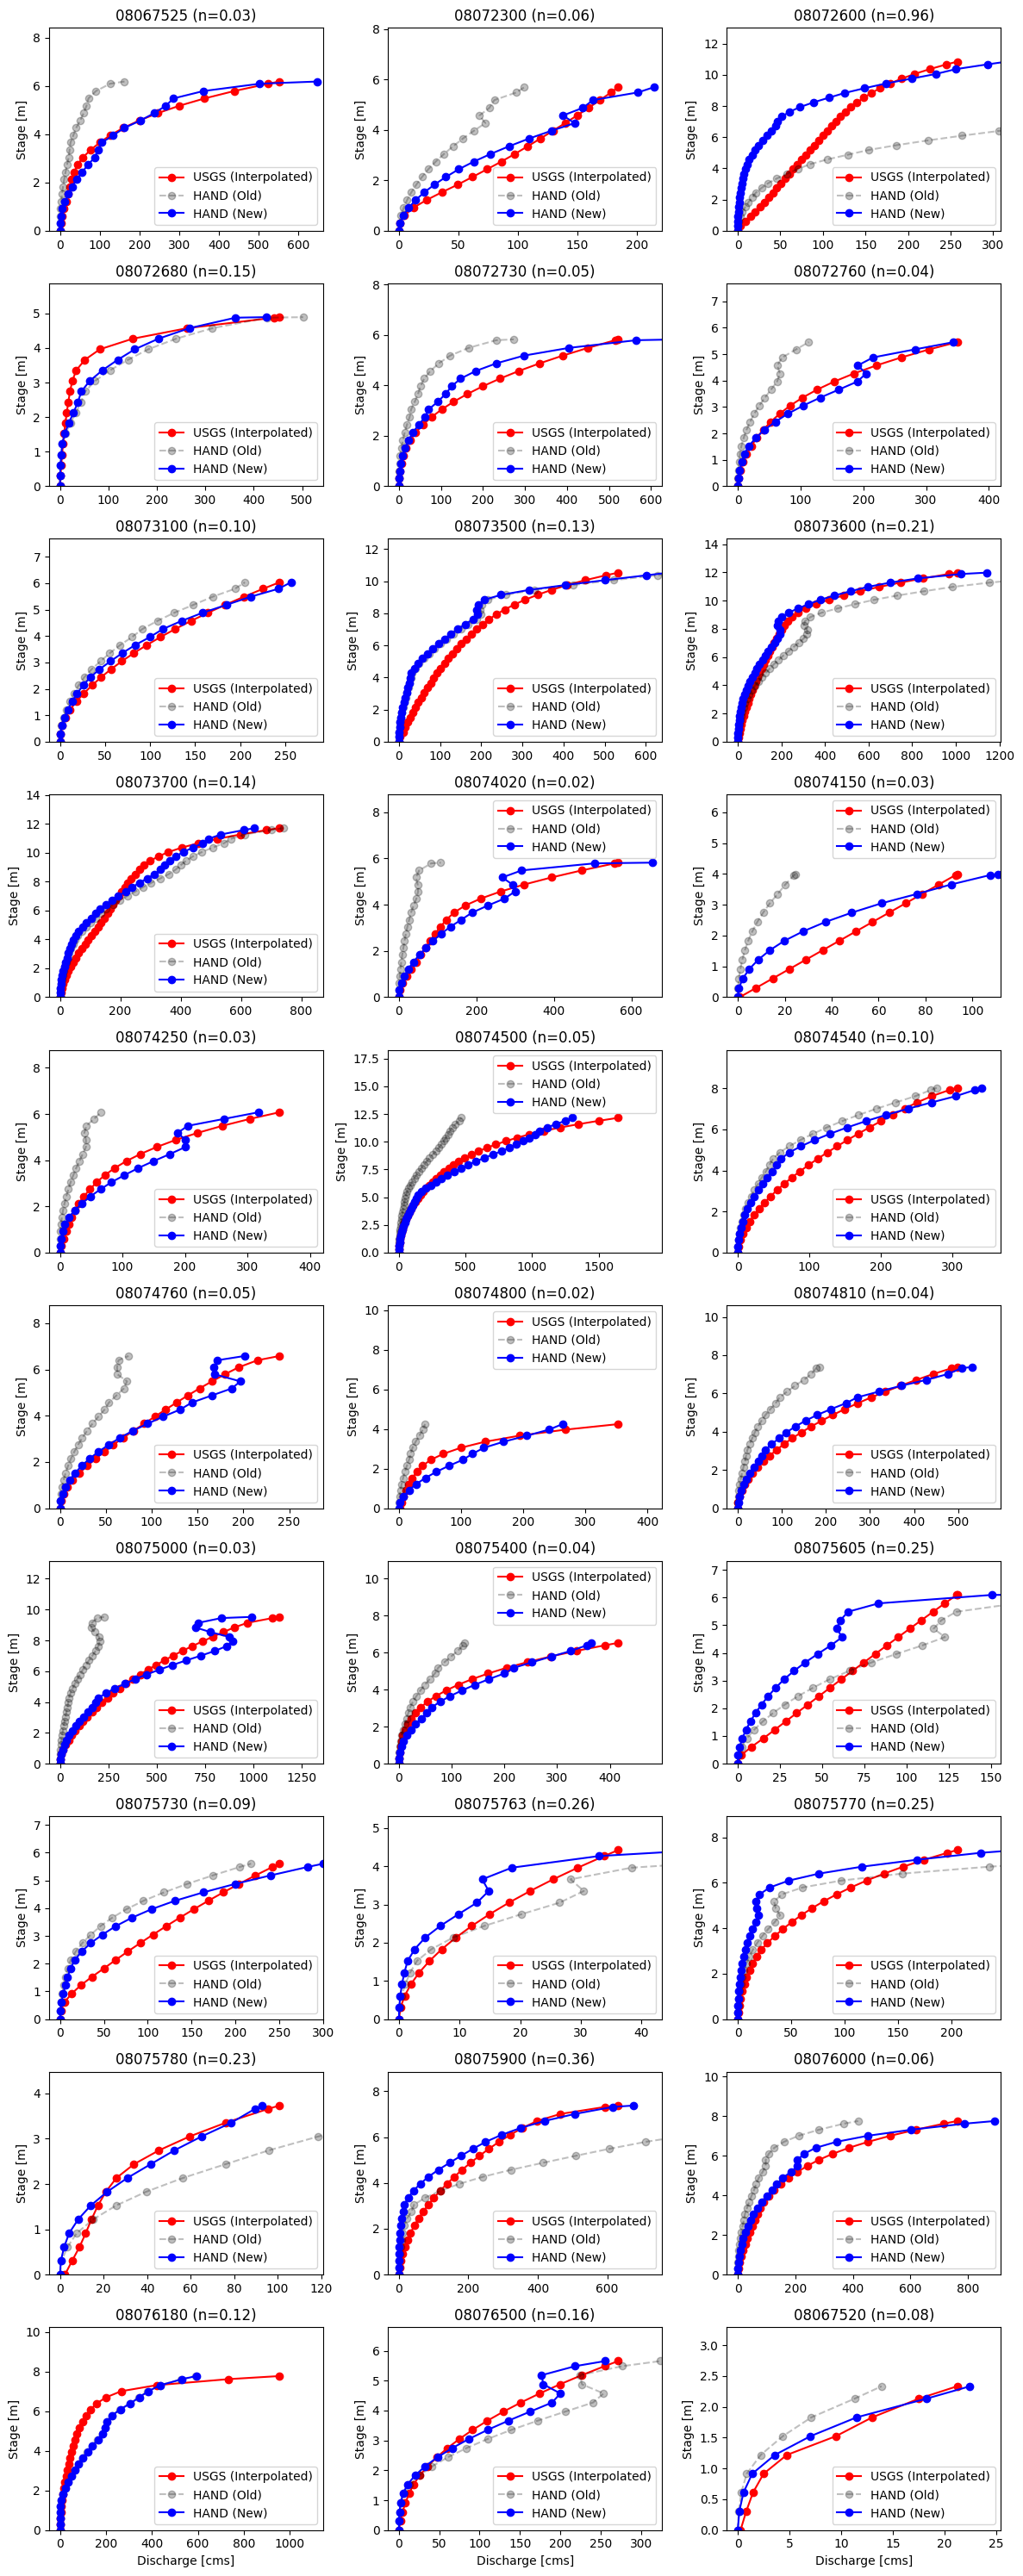

In [9]:
fig, ax = plt.subplots(len(valid_ids) // 3, 3, figsize=(12, len(valid_ids)))

for i, station_id in enumerate(valid_ids):
    usgs_rating = usgs_ratings[station_id]
    hand_rating = hand_ratings[station_id]
    # Calibration
    Qu, hu = usgs_rating['DEP'].values, usgs_rating['INDEP'].values
    interp = scipy.interpolate.CubicSpline(hu, Qu)
    hand_rating_mod = hand_rating.copy()
    hand_rating_mod.loc[hand_rating.index.max() + 1, hand_rating.columns] = [hu.max(), np.nan, np.nan, np.nan, np.nan, np.nan]
    hand_rating_mod = hand_rating_mod.sort_values('stage').interpolate()
    hand_in_range = hand_rating_mod[hand_rating_mod['stage'] <= hu.max()]
    Qh, hh, Ah, Rh, S_0h = (hand_in_range['discharge_cms'].values, hand_in_range['stage'].values, 
                            hand_in_range['WetArea (m2)'], hand_in_range['HydraulicRadius (m)'], 
                            hand_in_range['SLOPE'])
    hup, Qup = hh, np.maximum(interp(hh), 0.)
    opt_result = scipy.optimize.minimize_scalar(eval_curves, args=(Ah, Rh, S_0h, Qup), bracket=[1e-5, 1.])
    if not opt_result.success:
        raise ValueError
    n = opt_result.x
    hnew, Qnew = hh, eval_hand(n, Ah, Rh, S_0h)
    hold, Qold = hh, eval_hand(0.125, Ah, Rh, S_0h)
    # Plot results
    #usgs_rating.set_index('DEP')['INDEP'].plot(ax=ax[i], label='USGS', c='r', marker='o')
    ax.flat[i].plot(Qup, hup, label='USGS (Interpolated)', c='r', marker='o')
    ax.flat[i].plot(Qold, hold, label='HAND (Old)', c='k', alpha=0.25, linestyle='--', marker='o')
    ax.flat[i].plot(Qnew, hnew, label='HAND (New)', c='b', marker='o')
    usgs_max = usgs_rating['INDEP'].max()
    hand_max = hand_rating.loc[(hand_rating['discharge_cms'] - usgs_rating['DEP'].max()).abs().idxmin(), 'stage']
    ax.flat[i].set_xlim(-0.05 * usgs_rating['DEP'].max(), 1.2 * usgs_rating['DEP'].max())
    ax.flat[i].set_ylim(0, 1.2 * max(usgs_max, hand_max))
    ax.flat[i].set_xlabel('')
    ax.flat[i].set_ylabel('Stage [m]')
    ax.flat[i].legend()
    ax.flat[i].set_title(f'{station_id} (n={n:.2f})')

ax.flat[i-2].set_xlabel('Discharge [cms]')
ax.flat[i-1].set_xlabel('Discharge [cms]')
ax.flat[i].set_xlabel('Discharge [cms]')
plt.tight_layout()
